### Tutorial B8: Dependency Maps

> saliency + ersatz (substitute) + saliency

An attribution map tells you which bases matter. A <i>dependency map</i> tells you which bases decide whether the other bases matter.

The construction is in-silico saturation mutagenesis lifted one level up. [Saturation mutagenesis](Tutorial_B4_Saturation_Mutagenesis.ipynb) substitutes each base in turn and asks how the model's <i>scalar prediction</i> moves. A dependency map makes the same substitutions but asks how the model's <i>entire explanation of the sequence</i> moves. For each pair of positions (j, i) it records how far the attribution at position j travels when the base at position i is swapped.

Why that is interesting: a model that treats positions independently produces a purely diagonal map, because changing a base can only alter its own attribution. Any off-diagonal structure is therefore direct evidence of epistasis the model has learned. Two motifs that cooperate show up as an off-diagonal block linking them, and the flanking bases a motif depends on show up as stripes leading into it.

The cost follows from the construction: `(end - start) * (len(alphabet) - 1)` attributions per sequence. That is why the default attribution function is [`saliency`](Tutorial_A6_Saliency.ipynb), which needs only a single backward pass, and why you will almost always want to restrict the substituted region with `start`/`end`.

In [1]:
import torch
from model import Beluga

model = Beluga()
model.load_state_dict(torch.load("deepsea.beluga.torch", weights_only=False))

<All keys matched successfully>

#### Building a sequence with a known answer

Rather than starting from genomic sequence, we will plant two copies of the AP-1 motif into a random background at a known spacing. Because we chose where they are, we know exactly what structure the map should show, which makes it a good check that we are reading it correctly.

In [2]:
from tangermeme.utils import random_one_hot
from tangermeme.utils import characters
from tangermeme.ersatz import multisubstitute

X = random_one_hot((1, 4, 2000), random_state=0).type(torch.float32)
X = multisubstitute(X, ["GTGACTCATC", "GTGACTCATC"], [20])

characters(X[0, :, 975:1030])

'GACGAGTGACTCATCGAGAGAAGCATGTAAGTATCGTGACTCATCGGGGATGAAC'

`multisubstitute` centers the group, so the two motifs sit at roughly 980-990 and 1010-1020, separated by 20bp of background.

#### Basic Usage

`dependency_map` takes a model and a batch of sequences, and `start`/`end` restrict which positions get substituted. Any keyword it does not recognize &mdash; `target`, `batch_size`, `device` &mdash; is forwarded to the attribution function.

In [3]:
from tangermeme.dependency_map import dependency_map

dmap = dependency_map(model, X, start=975, end=1030, target=267, batch_size=64)
dmap.shape

torch.Size([1, 2000, 55])

The result is `(n_sequences, length, end - start)`. Note that the two axes are not symmetric and are not the same size: the columns are the positions we substituted, but the rows span the <i>whole</i> sequence, because substituting a base inside the window can move attributions anywhere. `dmap[:, j, i]` is the mean absolute change in the attribution at position `j` caused by substituting the base at position `start + i`.

For plotting we will slice the rows down to the same window as the columns.

In [4]:
d = dmap[0, 975:1030, :]
d.shape

torch.Size([55, 55])

#### The diagonal dominates, so mask it

Before plotting, one thing has to be dealt with. The diagonal of a dependency map measures the direct effect of a substitution on its <i>own</i> attribution. That is non-zero even for a model with no interactions at all, and it is typically several times larger than everything else, so it will swallow the color scale.

In [5]:
diagonal = torch.diag(d)
off_diagonal = d - torch.diag(diagonal)

print("mean on the diagonal:  %.4f" % diagonal.mean())
print("mean off the diagonal: %.4f" % off_diagonal[off_diagonal > 0].mean())

mean on the diagonal:  0.4547
mean off the diagonal: 0.0910


In [6]:
d_masked = d.clone()
d_masked.fill_diagonal_(0)
d_masked.max()

tensor(1.1693)

#### Plotting the map

We plot the masked map as a heatmap with the attribution logo underneath, so the structure can be read against the sequence itself.

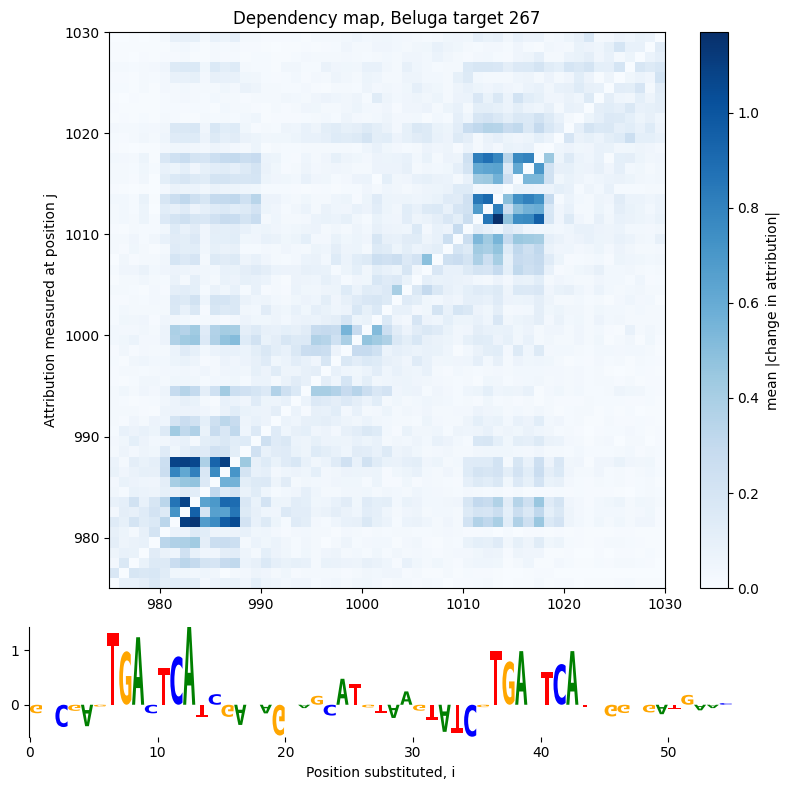

In [7]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from matplotlib import pyplot as plt
from tangermeme.plot import plot_logo
from tangermeme.saliency import saliency

X_attr = saliency(model, X, target=267)

fig = plt.figure(figsize=(8, 8))

ax0 = plt.subplot2grid((5, 1), (0, 0), rowspan=4)
im = ax0.imshow(d_masked.numpy(), cmap='Blues', origin='lower',
    extent=[975, 1030, 975, 1030])
ax0.set_ylabel("Attribution measured at position j")
ax0.set_title("Dependency map, Beluga target 267")
plt.colorbar(im, ax=ax0, fraction=0.046, label="mean |change in attribution|")

ax1 = plt.subplot2grid((5, 1), (4, 0))
plot_logo(X_attr[0, :, 975:1030], ax=ax1)
ax1.set_xlabel("Position substituted, i")

plt.tight_layout()
plt.show()

The two bright blocks on the diagonal are the motifs depending on themselves &mdash; substituting one base of an AP-1 site changes the attributions of the rest of that same site. The interesting part is the two <i>off</i>-diagonal blocks, which say that substituting a base in the first motif moves the attributions of the second motif, twenty base pairs away, and vice versa. The model has learned that these two sites are not independent.

#### Quantifying the blocks

Rather than reading the picture, we can measure it directly. We compare the average dependency within each block against the dependency between a motif and background sequence at increasing distance from it.

In [8]:
m1 = slice(980, 990)
m2 = slice(1010, 1020)
spacer = slice(995, 1005)
bg = slice(1040, 1060)

# The rows of dmap span the whole sequence, so they are indexed by genomic
# position; the columns only cover the substituted window and are offset.
cols = lambda s: slice(s.start - 975, s.stop - 975)
full = dmap[0]

print("motif 1 -> motif 1:      %.4f" % full[m1, cols(m1)].mean())
print("motif 1 -> motif 2:      %.4f" % full[m2, cols(m1)].mean())
print("motif 2 -> motif 1:      %.4f" % full[m1, cols(m2)].mean())
print("motif 1 -> spacer:       %.4f" % full[spacer, cols(m1)].mean())
print("motif 1 -> background:   %.4f" % full[bg, cols(m1)].mean())

motif 1 -> motif 1:      0.4469
motif 1 -> motif 2:      0.1454
motif 2 -> motif 1:      0.1353
motif 1 -> spacer:       0.1155
motif 1 -> background:   0.0407


Two things to read off this. The cross-motif dependency is several times the dependency on distal background sequence, and it is roughly symmetric in both directions, which is what genuine cooperativity between two sites should look like.

The spacer between the two motifs is also elevated, and sits between the two. That is not an artifact: dependency falls off with distance, so sequence immediately next to a motif is coupled to it more strongly than sequence far away. It is worth keeping in mind when reading a map, since it means proximity alone produces some off-diagonal signal &mdash; the evidence for cooperativity is the block at the *other* motif standing above that decaying background, not merely being non-zero.

#### Choosing the attribution function

`func` selects which attribution method is run before and after each substitution, and defaults to `saliency`. Anything satisfying the `func(model, X, args=, **kwargs)` contract and returning `(-1, len(alphabet), length)` works, so `deep_lift_shap` and `saturation_mutagenesis` can both be dropped in when their accuracy is worth the cost.

Since [saliency saturates](Tutorial_A6_Saliency.ipynb), it is worth checking that the structure survives a more careful attribution method. We use a narrower window to keep the cost down.

In [9]:
from tangermeme.deep_lift_shap import deep_lift_shap

# Beluga exceeds the default convergence-delta threshold, which would emit a
# warning for every one of the substitutions; Tutorial A3 covers what the
# deltas mean, so we raise the threshold to keep the output readable here.
dmap_dls = dependency_map(model, X, start=978, end=1022, target=267,
    func=deep_lift_shap, n_shuffles=3, random_state=0, batch_size=64,
    warning_threshold=1.0)

full_dls = dmap_dls[0]
cols_dls = lambda s: slice(s.start - 978, s.stop - 978)

print("motif 1 -> motif 2:      %.4f" % full_dls[m2, cols_dls(m1)].mean())
print("motif 1 -> background:   %.4f" % full_dls[bg, cols_dls(m1)].mean())

motif 1 -> motif 2:      0.0607
motif 1 -> background:   0.0129


The same qualitative conclusion holds: the two motifs depend on each other far more than either depends on the background.

#### Things to watch out for

- **The diagonal is not comparable to the rest of the map.** It is non-zero even for a model with no interactions, and it dominates any color scale. Mask it before plotting, as we did above. On a full-length map you can do this with `dmap.diagonal(dim1=-2, dim2=-1).zero_()`.
- **Cost is `(end - start) * (len(alphabet) - 1)` attributions per sequence.** Substituting all 2,000 positions of a Beluga input would mean 6,000 attributions for a single sequence. Restrict to the region of interest; the columns you get are identical to running the full sequence and slicing it.
- **`func` here is the plug-point, not a post-processing hook.** `saliency` and `saturation_mutagenesis` each take their own `func` argument, which collides with this one. Route the inner one through `additional_func_kwargs={'func': ...}`.
- **`func` must return `(-1, len(alphabet), length)`**, since the alphabet axis is summed to give one value per position. `predict` does not satisfy this, and `deep_lift_shap` will reject sequences containing `N` (all-zero) columns, which `saliency` accepts.
- **Substitutions that re-apply the base already present are skipped**, since their attributions are unchanged, and each position is averaged over only the substitutions that actually changed it. A position holding an `N` therefore averages over four substitutions rather than three, and stays on the same scale as every other position.